In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
import statsmodels.api as sm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from datetime import datetime, timedelta
import requests
import time
import ollama
from tqdm import tqdm
from gdeltdoc import GdeltDoc, Filters

c:\Users\USER\anaconda3\envs\homework\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
start_date = "2015-01-01"
end_date="2025-11-13"

tsla = yf.download("TSLA", start=start_date, end=end_date)

tsla = tsla.droplevel(level=1, axis=1)
tsla_org = tsla.asfreq('B')
tsla = tsla_org.interpolate(method='time')
tsla.tail()

C:\Users\USER\AppData\Local\Temp\ipykernel_31408\245185109.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsla = yf.download("TSLA", start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-11-06,445.910004,467.450012,435.089996,461.959991,109622900.0
2025-11-07,429.519989,439.359985,421.880005,437.920013,103471500.0
2025-11-10,445.230011,449.670013,433.359985,439.600006,76515900.0
2025-11-11,439.619995,442.489990,432.359985,439.399994,60533200.0
2025-11-12,430.600006,442.329987,426.559998,442.149994,58513500.0


In [21]:
NEWS_FILE = "financial_news.csv"
OUT_DAILY = "daily_news_finbert.csv"

df_news = pd.read_csv(NEWS_FILE)
df_news["dt"] = pd.to_datetime(df_news["dt"]).dt.date

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(device)
model.eval()

def finbert_score(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    inputs = tokenizer.encode_plus(text, return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        output = model(**inputs)
        logits = output.logits
        probs = torch.softmax(logits, dim=-1)[0].tolist()
    pos, neu, neg = probs  # FinBERT order: [positive, neutral, negative]
    return float(pos - neg)


df_news["sentiment"] = df_news["body"].fillna("").apply(finbert_score)

print("Aggregating to daily level...")
daily = (
    df_news
    .groupby(["dt"], as_index=False)
    .agg(
        sentiment_mean=("sentiment", "mean"),
    )
)

daily.to_csv(OUT_DAILY, index=False)
daily.head()


Using device: cuda
Aggregating to daily level...


,dt,sentiment_mean
0,2015-01-02,-0.721631
1,2015-01-05,-0.724211
2,2015-01-07,-0.588047
3,2015-01-12,0.072181
4,2015-01-13,-0.820676


In [23]:
tesla_tone

,datetime,Average Tone
0,2017-01-01,0.0699
1,2017-01-02,0.1921
2,2017-01-03,0.1024
3,2017-01-04,0.1565
4,2017-01-05,0.4377
...,...,...
3213,2025-11-09,0.7079
3214,2025-11-10,0.4921
3215,2025-11-11,-0.0350
3216,2025-11-12,-0.2206


In [24]:
gd = GdeltDoc()

f = Filters(
    keyword="Tesla",
    start_date="2017-01-01",
    end_date="2025-11-13"
)

tesla_tone = gd.timeline_search("timelinetone", f)
tesla_tone['datetime'] = tesla_tone['datetime'].dt.date

def get_score(date):
    # finbert_score = daily[daily.dt == date]
    # if not finbert_score.empty:
    #     return finbert_score['sentiment_mean'].item()
    gdelt_score = tesla_tone[tesla_tone.datetime == date]
    if not gdelt_score.empty:
        return -gdelt_score['Average Tone'].item()
    return 0.0

for dt in tsla.index:
    score = get_score(dt.date())
    tsla.loc[dt, 'sentiment'] = score    

In [20]:
tsla.corr() 

Price,Close,High,Low,Open,Volume,sentiment
Price,,,,,,
Close,1.000000,0.999550,0.999586,0.998968,-0.099676,0.235018
High,0.999550,1.000000,0.999507,0.999610,-0.095633,0.238313
Low,0.999586,0.999507,1.000000,0.999511,-0.105649,0.233130
Open,0.998968,0.999610,0.999511,1.000000,-0.100937,0.236448
Volume,-0.099676,-0.095633,-0.105649,-0.100937,1.000000,0.102980
sentiment,0.235018,0.238313,0.233130,0.236448,0.102980,1.000000


In [23]:
tsla.corr() #finbert score를 합치면 오히려 corr이 떨어짐 -> gdelt score만 활용

Price,Close,High,Low,Open,Volume,sentiment
Price,,,,,,
Close,1.000000,0.999550,0.999586,0.998968,-0.099676,-0.119303
High,0.999550,1.000000,0.999507,0.999610,-0.095633,-0.119514
Low,0.999586,0.999507,1.000000,0.999511,-0.105649,-0.119515
Open,0.998968,0.999610,0.999511,1.000000,-0.100937,-0.119503
Volume,-0.099676,-0.095633,-0.105649,-0.100937,1.000000,-0.107432
sentiment,-0.119303,-0.119514,-0.119515,-0.119503,-0.107432,1.000000


In [25]:
for lag in [1,2,3,5,10]:
  tsla[f"lag_{lag}"] = tsla['Close'].shift(lag)

for window in [5, 10, 20]:
  tsla[f"roll_mean_{window}"] = tsla['Close'].rolling(window=window).mean()

tsla['dayofweek'] = tsla.index.dayofweek
tsla['month'] = tsla.index.month

tsla["day_sin"] = np.sin(2 * np.pi * tsla["dayofweek"] / 5)
tsla["day_cos"] = np.cos(2 * np.pi * tsla["dayofweek"] / 5)
tsla["month_sin"] = np.sin(2 * np.pi * tsla["month"] / 12)
tsla["month_cos"] = np.cos(2 * np.pi * tsla["month"] / 12)

In [26]:
def train_test_split_series(series: pd.Series, test_size: int = 60):
    train = series.iloc[:-test_size]
    test  = series.iloc[-test_size:]
    return train, test

def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE(%)": mape}

test_ratio = 0.2
test_size = int(len(tsla) * test_ratio)
train_d, test_d = train_test_split_series(tsla['Close'], test_size=test_size)
len(train_d), len(test_d)

(2268, 566)

In [27]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


class TimeSeriesDataset(Dataset):
    def __init__(self, df, window_size, feature_scaler=None, target_scaler=None, label_col='Close'):
        self.window_size = window_size

        features = df.drop(columns=[label_col]).values.astype(np.float32)
        target = df[label_col].values.astype(np.float32)


        X = feature_scaler.transform(features)
        y = target_scaler.transform(target.reshape(-1, 1)).flatten()

        Xs = []
        ys = []
        for i in range(window_size, len(X)):
            Xs.append(X[i - window_size : i])
            ys.append(y[i])
        self.Xs = np.stack(Xs)
        self.ys = np.array(ys)

        assert not np.isnan(Xs).any(), "Input X has NaN!"
        assert not np.isinf(Xs).any(), "Input X has Inf!"
        assert not np.isnan(ys).any(), "y has NaN!"
        assert not np.isinf(ys).any(), "y has Inf!"

    def __len__(self):
        return len(self.ys)

    def __getitem__(self, idx):
        return self.Xs[idx], self.ys[idx]

In [28]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


class TimeSeriesDataset(Dataset):
    def __init__(self, df, window_size, feature_scaler=None, target_scaler=None, label_col='Close'):
        self.window_size = window_size

        features = df.drop(columns=[label_col]).values.astype(np.float32)
        target = df[label_col].values.astype(np.float32)


        X = feature_scaler.transform(features)
        y = target_scaler.transform(target.reshape(-1, 1)).flatten()

        Xs = []
        ys = []
        for i in range(window_size, len(X)):
            Xs.append(X[i - window_size : i])
            ys.append(y[i])
        self.Xs = np.stack(Xs)
        self.ys = np.array(ys)

        assert not np.isnan(Xs).any(), "Input X has NaN!"
        assert not np.isinf(Xs).any(), "Input X has Inf!"
        assert not np.isnan(ys).any(), "y has NaN!"
        assert not np.isinf(ys).any(), "y has Inf!"

    def __len__(self):
        return len(self.ys)

    def __getitem__(self, idx):
        return self.Xs[idx], self.ys[idx]



class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        y = self.fc(out)
        return y.view(-1)


In [43]:
from torch.utils.data import Subset, DataLoader
import os

def get_scaler(df, train_fraction=0.8, label_col='Close'):
    train_df, _ = train_test_split_series(df, test_size=int(len(df) * (1 - train_fraction)))
    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()
    X_scaler.fit(train_df.drop(columns=[label_col]))
    y_scaler.fit(train_df[label_col].values.reshape(-1, 1))
    return X_scaler, y_scaler

def prepare_dataset(df, window_size=60, X_scaler=None, y_scaler=None, train_fraction=0.8, batch_size=32):
    dataset = TimeSeriesDataset(df, window_size, X_scaler, y_scaler)

    n = len(dataset)
    train_size = int(n * train_fraction)
    test_size = n - train_size

    train_indices = list(range(0, train_size))
    test_indices = list(range(train_size, n))

    train_ds = Subset(dataset, train_indices)
    test_ds = Subset(dataset, test_indices)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def train_lstm(train_loader, test_loader, X_scaler, y_scaler, epochs=50, lr=1e-4, device=None, input_size=15, model=None):
    if model is None:
        model = LSTMRegressor(input_size=input_size).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_results = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for X, y in train_loader:
            X= X.to(device)
            y = y.to(device)
            y_pred = model(X)
            loss = criterion(y_pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            model.eval()
            all_preds = []
            all_targets = []
            with torch.no_grad():
                for X, y in test_loader:
                    X = X.to(device)
                    y = y.to(device)
                    y_pred = model(X)
                    all_preds.append(y_pred.cpu().numpy())
                    all_targets.append(y.cpu().numpy())

            all_preds = np.concatenate(all_preds)
            all_targets = np.concatenate(all_targets)

            preds_rescaled = y_scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
            targets_rescaled = y_scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()

            m = metrics(targets_rescaled, preds_rescaled)
            m['epoch'] = epoch
            train_results.append(m)

            mae = m['MAE']
            rmse = m['RMSE']

            print(f"Epoch {epoch}: train_loss={total_loss:.3f}, test_mae={mae:.3f}, test_rmse={rmse:.3f}")

    train_results = pd.DataFrame(train_results).set_index("epoch")

    return model, train_results


In [53]:
tsla_lstm = tsla.dropna().reset_index(drop=True).drop(columns=['High', 'Low', 'Open', 'Volume'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_scaler, y_scaler = get_scaler(tsla_lstm)
train_loader, test_loader = prepare_dataset(tsla_lstm, X_scaler=X_scaler, y_scaler=y_scaler)
model_60, train_results_60 = train_lstm(train_loader, test_loader, X_scaler, y_scaler, device=device)
print(train_results_60)

c:\Users\USER\anaconda3\envs\homework\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Epoch 4: train_loss=0.411, test_mae=28.117, test_rmse=35.779
Epoch 9: train_loss=0.258, test_mae=27.679, test_rmse=36.882
Epoch 14: train_loss=0.228, test_mae=26.871, test_rmse=36.221
Epoch 19: train_loss=0.227, test_mae=27.050, test_rmse=36.362
Epoch 24: train_loss=0.239, test_mae=26.507, test_rmse=35.572
Epoch 29: train_loss=0.206, test_mae=25.273, test_rmse=33.690
Epoch 34: train_loss=0.208, test_mae=24.580, test_rmse=32.847
Epoch 39: train_loss=0.168, test_mae=22.990, test_rmse=30.362
Epoch 44: train_loss=0.171, test_mae=22.123, test_rmse=29.199
Epoch 49: train_loss=0.163, test_mae=22.056, test_rmse=29.372
             MAE       RMSE    MAPE(%)
epoch                                 
4      28.117191  35.779434  10.115624
9      27.679499  36.882450   9.271487
14     26.870523  36.220688   8.994741
19     27.049774  36.361916   9.005037
24     26.506548  35.571724   8.818116
29     25.273014  33.690315   8.534083
34     24.579863  32.847027   8.261460
39     22.989740  30.361765   7

In [54]:
tsla_lstm = tsla.dropna().reset_index(drop=True).drop(columns=['High', 'Low', 'Open', 'Volume'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_scaler, y_scaler = get_scaler(tsla_lstm)
train_loader, test_loader = prepare_dataset(tsla_lstm, X_scaler=X_scaler, y_scaler=y_scaler, window_size=20)
model_20, train_results_20 = train_lstm(train_loader, test_loader, X_scaler, y_scaler, device=device)
print(train_results_20)

c:\Users\USER\anaconda3\envs\homework\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Epoch 4: train_loss=0.295, test_mae=26.227, test_rmse=34.088
Epoch 9: train_loss=0.210, test_mae=24.962, test_rmse=33.896
Epoch 14: train_loss=0.208, test_mae=26.784, test_rmse=36.358
Epoch 19: train_loss=0.218, test_mae=25.954, test_rmse=34.803
Epoch 24: train_loss=0.208, test_mae=24.686, test_rmse=32.602
Epoch 29: train_loss=0.181, test_mae=24.301, test_rmse=32.494
Epoch 34: train_loss=0.170, test_mae=22.672, test_rmse=29.835
Epoch 39: train_loss=0.172, test_mae=23.117, test_rmse=30.515
Epoch 44: train_loss=0.163, test_mae=22.722, test_rmse=30.169
Epoch 49: train_loss=0.179, test_mae=22.171, test_rmse=29.308
             MAE       RMSE   MAPE(%)
epoch                                
4      26.226614  34.087914  9.121082
9      24.962006  33.895515  8.345209
14     26.783649  36.358387  8.757625
19     25.954180  34.802818  8.651480
24     24.686014  32.602177  8.447145
29     24.301062  32.493671  8.145205
34     22.671511  29.834976  7.860260
39     23.117031  30.515438  7.909159
44

In [60]:
tsla_lstm = tsla.dropna().reset_index(drop=True).drop(columns=['High', 'Low', 'Open', 'Volume'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_scaler, y_scaler = get_scaler(tsla_lstm)
train_loader, test_loader = prepare_dataset(tsla_lstm, X_scaler=X_scaler, y_scaler=y_scaler, window_size=100)
model_100, train_results_100 = train_lstm(train_loader, test_loader, X_scaler, y_scaler, device=device)
print(train_results_100)

c:\Users\USER\anaconda3\envs\homework\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Epoch 4: train_loss=0.400, test_mae=26.283, test_rmse=34.806
Epoch 9: train_loss=0.217, test_mae=26.714, test_rmse=36.292
Epoch 14: train_loss=0.204, test_mae=27.842, test_rmse=37.560
Epoch 19: train_loss=0.191, test_mae=26.041, test_rmse=34.541
Epoch 24: train_loss=0.173, test_mae=25.244, test_rmse=33.478
Epoch 29: train_loss=0.168, test_mae=23.871, test_rmse=31.592
Epoch 34: train_loss=0.185, test_mae=23.525, test_rmse=30.761
Epoch 39: train_loss=0.166, test_mae=23.095, test_rmse=30.234
Epoch 44: train_loss=0.148, test_mae=21.862, test_rmse=28.225
Epoch 49: train_loss=0.147, test_mae=21.790, test_rmse=28.232
             MAE       RMSE   MAPE(%)
epoch                                
4      26.283100  34.805935  8.959816
9      26.714409  36.292271  8.809667
14     27.842033  37.559525  9.071508
19     26.041286  34.540829  8.792715
24     25.243671  33.478043  8.517342
29     23.871166  31.591888  8.134616
34     23.524805  30.760855  8.124253
39     23.094810  30.233574  7.938971
44

In [61]:
tsla_lstm = tsla.dropna().reset_index(drop=True).drop(columns=['High', 'Low', 'Open', 'Volume'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_scaler, y_scaler = get_scaler(tsla_lstm)
train_loader, test_loader = prepare_dataset(tsla_lstm, X_scaler=X_scaler, y_scaler=y_scaler, window_size=10)
model_10, train_results_10 = train_lstm(train_loader, test_loader, X_scaler, y_scaler, device=device)
print(train_results_10)

c:\Users\USER\anaconda3\envs\homework\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Epoch 4: train_loss=0.394, test_mae=23.994, test_rmse=31.286
Epoch 9: train_loss=0.206, test_mae=24.751, test_rmse=33.456
Epoch 14: train_loss=0.197, test_mae=26.121, test_rmse=35.384
Epoch 19: train_loss=0.191, test_mae=27.330, test_rmse=36.895
Epoch 24: train_loss=0.186, test_mae=26.229, test_rmse=35.374
Epoch 29: train_loss=0.169, test_mae=25.023, test_rmse=33.543
Epoch 34: train_loss=0.166, test_mae=24.275, test_rmse=32.477
Epoch 39: train_loss=0.151, test_mae=23.228, test_rmse=31.076
Epoch 44: train_loss=0.154, test_mae=23.230, test_rmse=30.928
Epoch 49: train_loss=0.136, test_mae=22.064, test_rmse=29.480
             MAE       RMSE   MAPE(%)
epoch                                
4      23.994019  31.285982  8.524549
9      24.751146  33.456188  8.298886
14     26.120922  35.383781  8.605665
19     27.330124  36.895073  8.885352
24     26.229439  35.373543  8.629548
29     25.022650  33.542809  8.378868
34     24.274733  32.476822  8.173916
39     23.227596  31.075785  7.874457
44

In [42]:
import torch
import torch.nn as nn

class FinBERTLSTM(nn.Module):
    def __init__(self,
                 input_size,
                 hidden_sizes=(50, 30, 20),
                 dropout_rates=(0.1, 0.05, 0.01)):
        super().__init__()

        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_sizes[0],
            num_layers=1,
            batch_first=True,
        )
        self.drop1 = nn.Dropout(dropout_rates[0])

        self.lstm2 = nn.LSTM(
            input_size=hidden_sizes[0],
            hidden_size=hidden_sizes[1],
            num_layers=1,
            batch_first=True,
        )
        self.drop2 = nn.Dropout(dropout_rates[1])

        self.lstm3 = nn.LSTM(
            input_size=hidden_sizes[1],
            hidden_size=hidden_sizes[2],
            num_layers=1,
            batch_first=True,
        )
        self.drop3 = nn.Dropout(dropout_rates[2])

        self.fc = nn.Linear(hidden_sizes[2], 1)


    def forward(self, x):
        out1, _ = self.lstm1(x)              
        out1 = self.drop1(out1)

        out2, _ = self.lstm2(out1)           
        out2 = self.drop2(out2)

        out3, (h_n, c_n) = self.lstm3(out2)  
        out3 = self.drop3(out3)

        h_last = h_n[-1]                   

        y = self.fc(h_last)                 
        return y.view(-1)


In [68]:
tsla_lstm = tsla.dropna().reset_index(drop=True).drop(columns=['High', 'Low', 'Open', 'Volume'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FinBERTLSTM(input_size=15).to(device)
X_scaler, y_scaler = get_scaler(tsla_lstm)
train_loader, test_loader = prepare_dataset(tsla_lstm, X_scaler=X_scaler, y_scaler=y_scaler, window_size=10)
model_10_c, train_results_10_c = train_lstm(train_loader, test_loader, X_scaler, y_scaler, device=device, model=model, lr=1e-3)
print(train_results_10_c)

c:\Users\USER\anaconda3\envs\homework\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Epoch 4: train_loss=0.502, test_mae=45.812, test_rmse=66.508
Epoch 9: train_loss=0.411, test_mae=39.767, test_rmse=55.239
Epoch 14: train_loss=0.314, test_mae=34.035, test_rmse=47.427
Epoch 19: train_loss=0.246, test_mae=30.445, test_rmse=42.320
Epoch 24: train_loss=0.145, test_mae=27.008, test_rmse=36.935
Epoch 29: train_loss=0.103, test_mae=24.282, test_rmse=32.727
Epoch 34: train_loss=0.091, test_mae=22.629, test_rmse=30.096
Epoch 39: train_loss=0.083, test_mae=20.645, test_rmse=27.328
Epoch 44: train_loss=0.073, test_mae=21.119, test_rmse=27.918
Epoch 49: train_loss=0.072, test_mae=20.461, test_rmse=26.993
             MAE       RMSE    MAPE(%)
epoch                                 
4      45.812134  66.507820  13.902217
9      39.766521  55.239105  12.695186
14     34.035309  47.426701  10.828127
19     30.445480  42.320190   9.661794
24     27.008133  36.935158   8.684685
29     24.282267  32.727051   7.949626
34     22.629173  30.095585   7.526702
39     20.644882  27.327677   7

In [92]:
tsla_lstm = tsla.dropna().reset_index(drop=True).drop(columns=['High', 'Low', 'Open', 'Volume'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FinBERTLSTM(input_size=15, hidden_sizes=(64, 32, 16)).to(device)
X_scaler, y_scaler = get_scaler(tsla_lstm)
train_loader, test_loader = prepare_dataset(tsla_lstm, X_scaler=X_scaler, y_scaler=y_scaler, window_size=10)
model_10_c2, train_results_10_c2 = train_lstm(train_loader, test_loader, X_scaler, y_scaler, device=device, model=model, lr=2e-3, epochs=70)
print(train_results_10_c2)

c:\Users\USER\anaconda3\envs\homework\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Epoch 4: train_loss=6.787, test_mae=155.085, test_rmse=176.249
Epoch 9: train_loss=0.702, test_mae=60.228, test_rmse=79.889
Epoch 14: train_loss=0.539, test_mae=44.118, test_rmse=59.809
Epoch 19: train_loss=0.232, test_mae=34.221, test_rmse=48.880
Epoch 24: train_loss=0.147, test_mae=29.585, test_rmse=41.377
Epoch 29: train_loss=0.104, test_mae=26.962, test_rmse=37.001
Epoch 34: train_loss=0.101, test_mae=27.143, test_rmse=36.852
Epoch 39: train_loss=0.107, test_mae=21.868, test_rmse=28.241
Epoch 44: train_loss=0.069, test_mae=21.113, test_rmse=28.838
Epoch 49: train_loss=0.071, test_mae=19.788, test_rmse=26.903
Epoch 54: train_loss=0.095, test_mae=22.565, test_rmse=29.376
Epoch 59: train_loss=0.089, test_mae=30.034, test_rmse=41.183
Epoch 64: train_loss=0.071, test_mae=24.709, test_rmse=34.431
Epoch 69: train_loss=0.067, test_mae=22.010, test_rmse=31.003
              MAE        RMSE    MAPE(%)
epoch                                   
4      155.084702  176.248581  51.878231
9       6

In [82]:
model_10_c.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)
        y_pred = model_10_c(X)
        all_preds.append(y_pred.cpu().numpy())
        all_targets.append(y.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

preds_rescaled = y_scaler.inverse_transform(all_preds.reshape(-1, 1)).flatten()
targets_rescaled = y_scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()


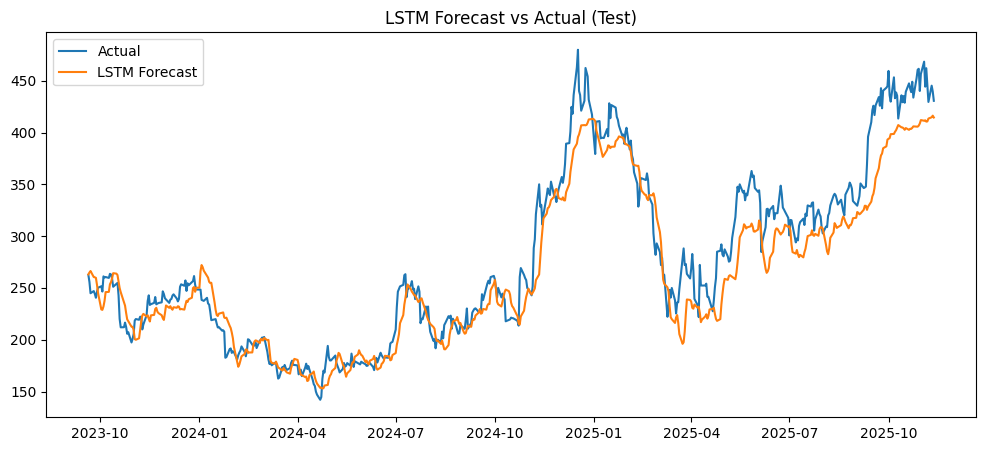

In [ ]:
plt.figure(figsize=(12,5))
pred_len = len(preds_rescaled)
plt.plot(test_d.iloc[-pred_len:].index, test_d.values[-pred_len:], label="Actual")
plt.plot(test_d.iloc[-pred_len:].index, preds_rescaled[-pred_len:], label="LSTM Forecast")
plt.title("LSTM Forecast vs Actual (Test)")
plt.legend()
plt.show()

#final performance
#MAE: 20.461279  RSME: 26.993372   MAPE: 6.958677